In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import scanpy.external as sce
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns
import os
import gc
import random
from scipy.sparse import csr_matrix, csc_matrix
from scipy.io import mmread
from scipy.stats import mannwhitneyu

In [2]:
sc.logging.print_header()
sc.settings.set_figure_params(dpi_save=600, facecolor='white', fontsize=7, format='pdf')

scanpy==1.10.3 anndata==0.10.9 umap==0.5.7 numpy==1.26.4 scipy==1.11.4 pandas==2.2.3 scikit-learn==1.5.2 statsmodels==0.14.4 igraph==0.11.8 louvain==0.8.1 pynndescent==0.5.13


In [3]:
random.seed(71444)

In [4]:
ad.logging.print_memory_usage()

Memory usage: current 0.55 GB, difference +0.55 GB


In [5]:
path = '/cluster/home/chenyulong/GSE165816/DFU' 
files = os.listdir(path) 
sample = [s[s.find('_')+1:s.find('.')] for s in files] #cut strings
sample = [s.replace('counts', '') for s in sample]

In [6]:
sample

['G1A',
 'G2',
 'G2A',
 'G3',
 'G3A',
 'G4',
 'G5',
 'G6',
 'G7',
 'G8',
 'G9',
 'G15',
 'G23',
 'G33',
 'G34',
 'G38',
 'G39',
 'G41',
 'G42',
 'G45',
 'G46',
 'G49']

In [8]:
%%time
adatas = []
for file in files: #read files
        sub_adata = sc.read_csv(path+"/"+file, first_column_names=None, dtype='float32').T
        sub_adata.X = csr_matrix(sub_adata.X)
        print(f"{file[11:-13]}:{sub_adata.X.shape}")
        adatas.append(sub_adata) 
adata = ad.concat(adatas, join="outer")
adata.obs['sample'] = ad.concat(adatas, label="sample", keys=sample).obs

G1A:(985, 14364)
G2:(3951, 18099)
G2A:(542, 14513)
G3:(1984, 17546)
G3A:(1011, 14939)
G4:(2865, 18239)
G5:(2630, 18548)
G6:(2279, 17753)
G7:(1775, 17981)
G8:(2417, 17828)
G9:(4290, 18475)
G15:(2250, 18349)
G23:(4630, 19611)
G33:(4268, 20512)
G34:(3413, 20279)
G38:(1475, 17492)
G39:(2899, 18437)
G41:(2437, 17954)
G42:(2235, 18215)
G45:(4202, 18900)
G46:(1659, 17872)
G49:(4040, 19030)


/cluster/home/chenyulong/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


CPU times: user 2min 3s, sys: 2.84 s, total: 2min 6s
Wall time: 2min 11s


/cluster/home/chenyulong/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [9]:
del sub_adata

In [10]:
gc.collect() # Garbage Collector
ad.logging.print_memory_usage()

Memory usage: current 2.82 GB, difference +2.27 GB


In [11]:
outdir = '/cluster/home/chenyulong/GSE165816/0.1out'
os.chdir(outdir)
adata.write("raw.h5ad")

## QC

In [12]:
adata = sc.read_h5ad("raw.h5ad")

/cluster/home/chenyulong/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [13]:
adata.obs

,sample
AAACCTGCATGTAAGA,G1A
AAACCTGGTGTGACGA,G1A
AAACGGGAGGCTACGA,G1A
AAACGGGTCTTGTTTG,G1A
AAAGATGGTCAGAGGT,G1A
...,...
TTTGTTGAGGAGGCAG-1,G49
TTTGTTGAGTAGGGTC-1,G49
TTTGTTGCACCTCGTT-1,G49
TTTGTTGTCGATACGT-1,G49


In [12]:
%%time
sce.pp.scrublet(adata) # 双细胞

/cluster/home/tmp02/.local/lib/python3.9/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function scrublet is deprecated; Import from sc.pp instead
  warnings.warn(msg, category=FutureWarning)


CPU times: user 15min 22s, sys: 8min 34s, total: 23min 56s
Wall time: 12min 37s


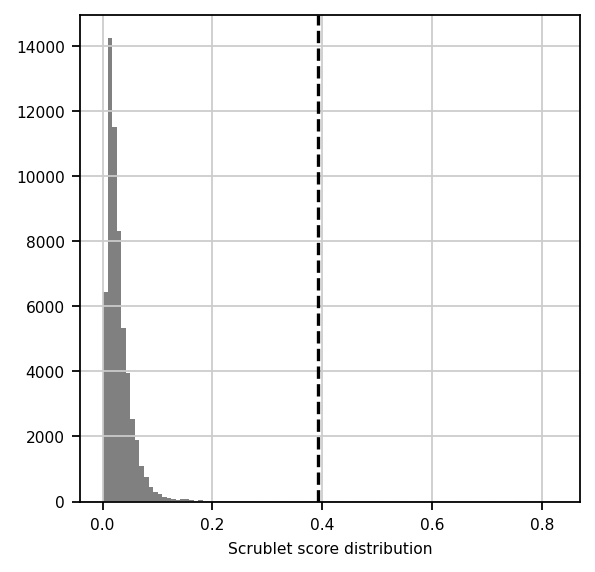

In [13]:
def plot_scrublet_scores(adata, ax):
    thr =  adata.uns['scrublet']['threshold']
    # Plot histogram
    ax.hist(adata.obs['doublet_score'], bins=100, color='gray')
    ax.axvline(x=thr, linestyle='--', color="black")
    ax.set_xlabel('Scrublet score distribution')

# Plot
fig, ax = plt.subplots(1, 1)
plot_scrublet_scores(adata, ax)

In [14]:
n0 = adata.shape[0]
print(f'Original cell number: {n0}')
adata = adata[adata.obs['doublet_score']<0.4, :]
n1 = adata.shape[0]
print(f'Cells retained after scrublet: {n1}, {n0-n1} removed.')

Original cell number: 58237
Cells retained after scrublet: 58027, 210 removed.


In [15]:
sc.pp.filter_cells(adata, min_genes=200) 
sc.pp.filter_genes(adata, min_cells=3) 
adata.var['mt'] = adata.var_names.str.startswith('MT-')  
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

/cluster/home/tmp02/.local/lib/python3.9/site-packages/scanpy/preprocessing/_simple.py:167: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["n_genes"] = number
/cluster/home/tmp02/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


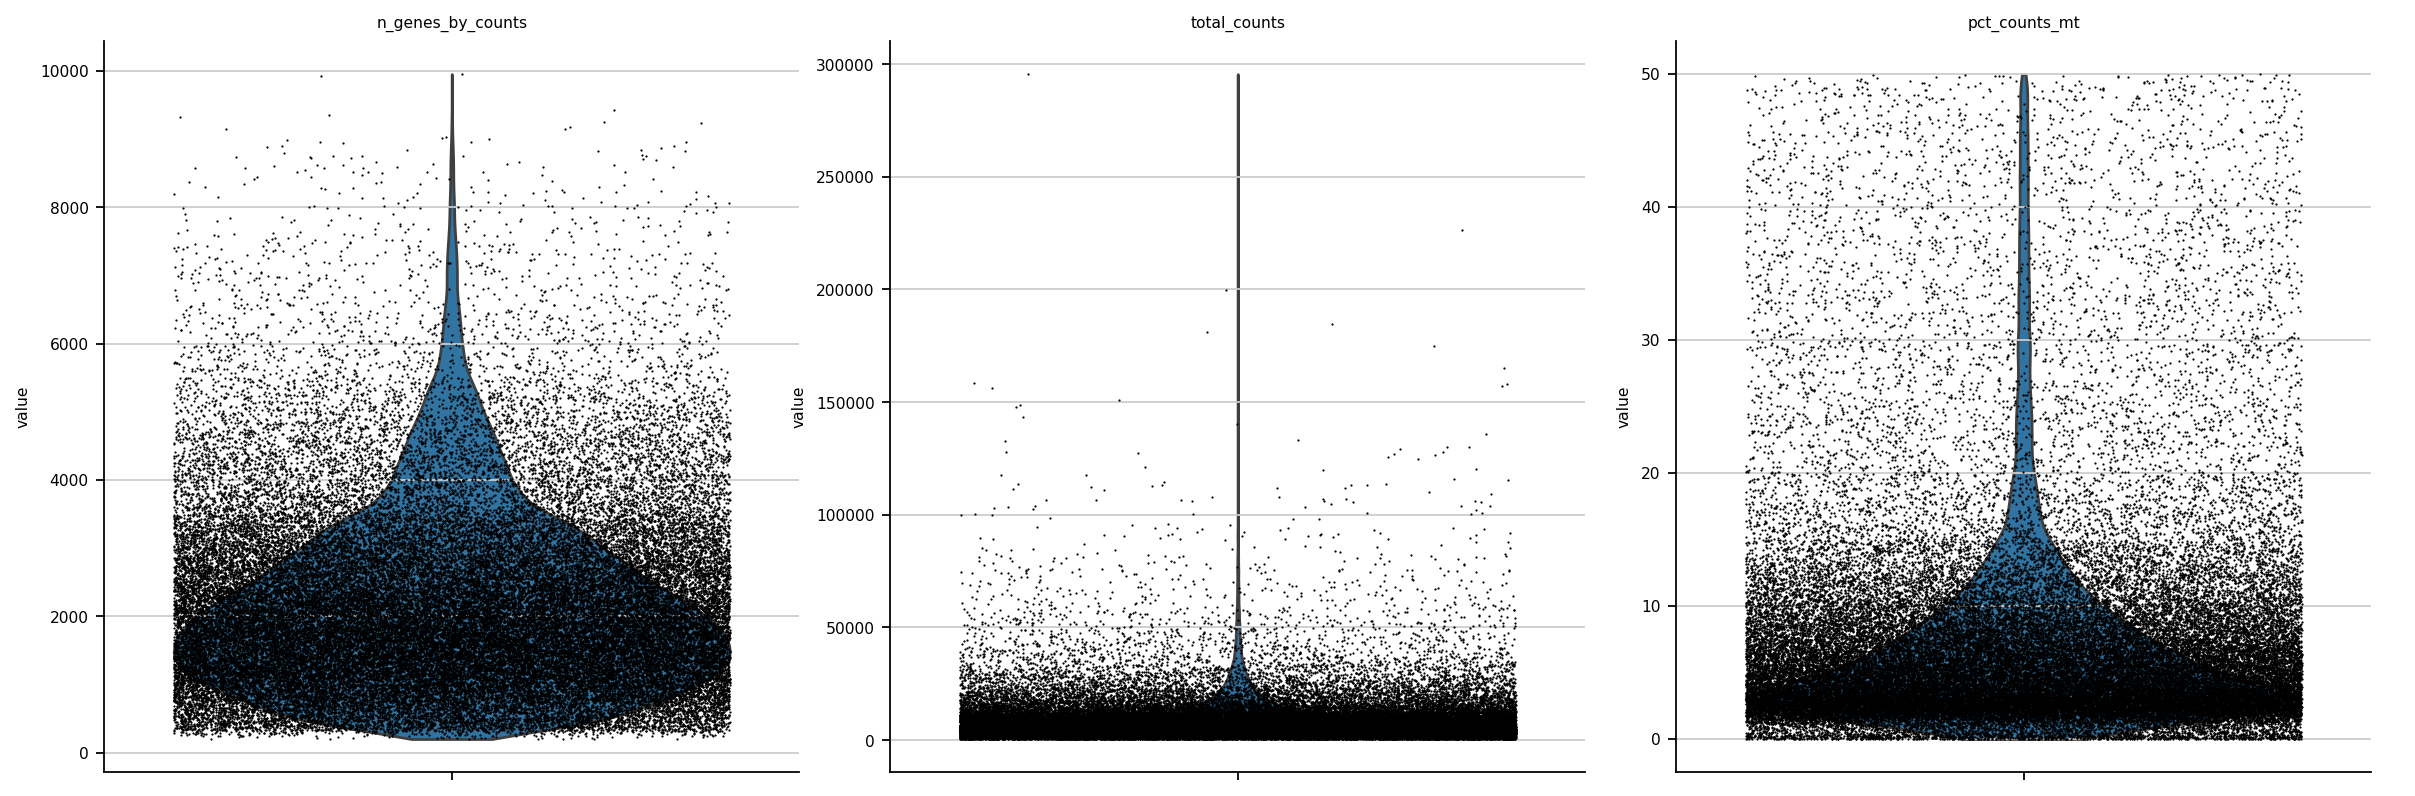

In [16]:
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],save='.pdf',
             jitter=0.4, multi_panel=True) 

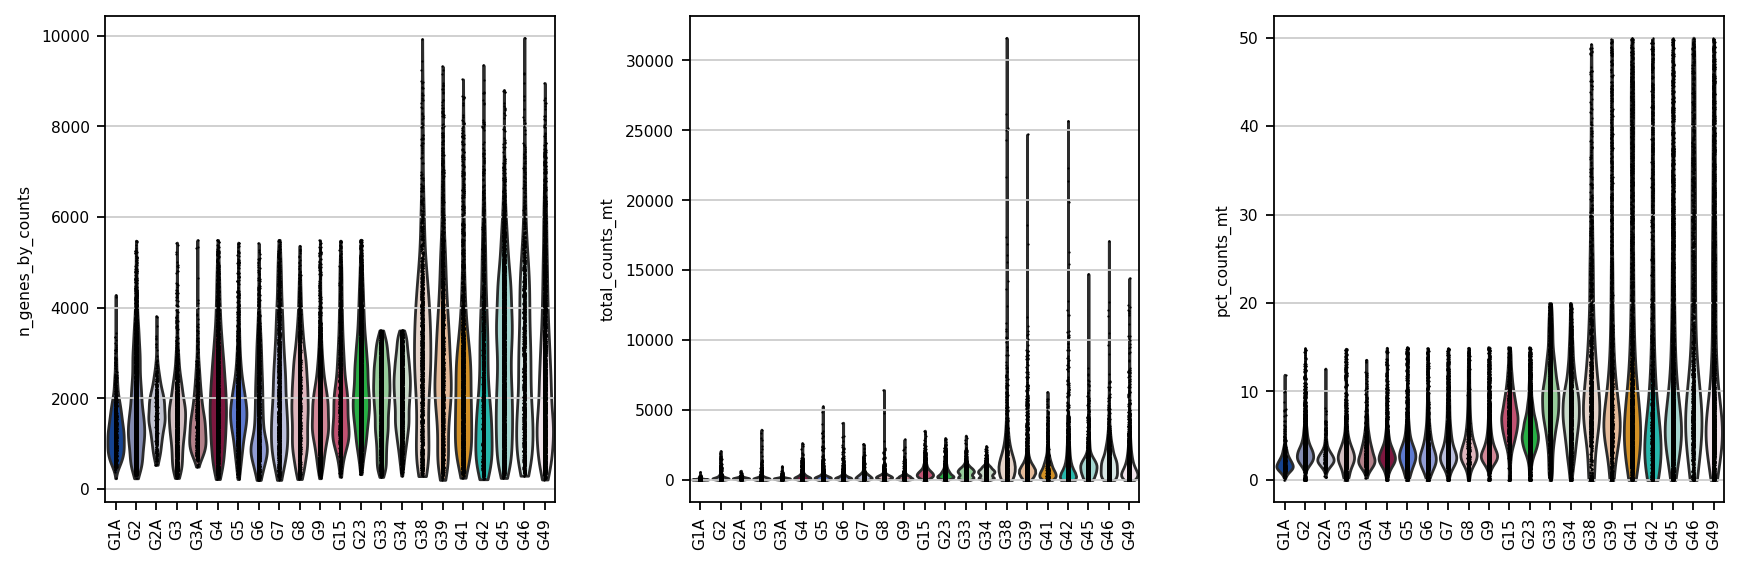

In [17]:
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts_mt', 'pct_counts_mt'],save='.groupby.pdf', groupby='sample', 
             jitter=0.05, rotation=90, multi_panel=True) 

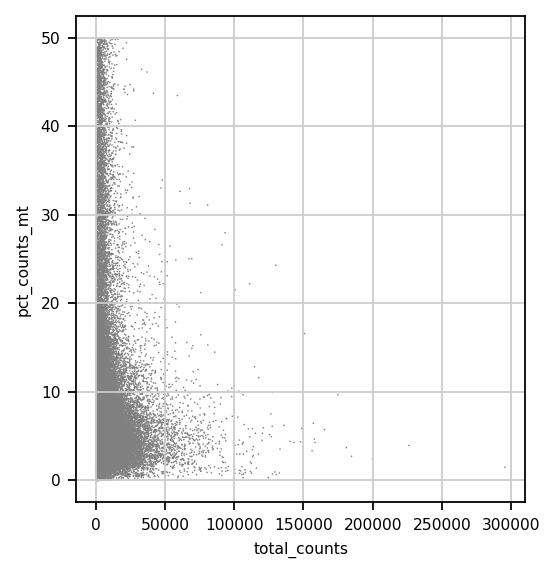

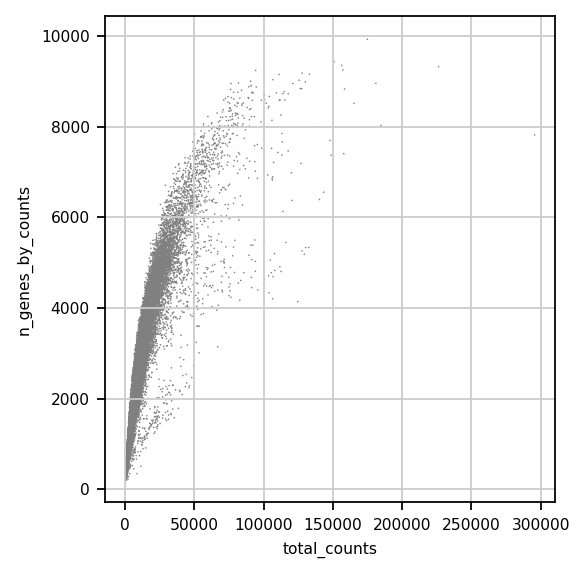

In [18]:
sc.pl.scatter(adata, x='total_counts', y='pct_counts_mt',save='.1.pdf')
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts',save='.2.pdf')

In [19]:
adata.shape

(58027, 24196)

In [20]:
adata[
(adata.obs.pct_counts_mt < 20) &
(adata.obs.n_genes_by_counts <4000) & 
(adata.obs.total_counts > 600) &
(adata.obs.total_counts < 40000),:].shape

(47754, 24196)

In [21]:
adata=adata[
(adata.obs.pct_counts_mt < 20) &
(adata.obs.n_genes_by_counts < 4000) & 
(adata.obs.total_counts > 600) &
(adata.obs.total_counts < 40000),:]

In [22]:
sample = np.unique(adata.obs['sample'])
for val in sample:
    print('Num of {} : {}'.format(val, adata[adata.obs['sample']==val].shape[0]))
    
print('total cells: ', adata.obs.shape[0])

Num of G15 : 2073
Num of G1A : 981
Num of G2 : 3738
Num of G23 : 4131
Num of G2A : 542
Num of G3 : 1907
Num of G33 : 4200
Num of G34 : 3384
Num of G38 : 805
Num of G39 : 1820
Num of G3A : 1004
Num of G4 : 2601
Num of G41 : 1493
Num of G42 : 1419
Num of G45 : 2161
Num of G46 : 742
Num of G49 : 2091
Num of G5 : 2519
Num of G6 : 2166
Num of G7 : 1562
Num of G8 : 2280
Num of G9 : 4135
total cells:  47754


In [23]:
adata.write('QC.h5ad')

## NOMALIZATION

In [15]:
adata = sc.read_h5ad('/cluster/home/chenyulong/GSE165816/0.1out/QC.h5ad')

/cluster/home/chenyulong/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [17]:
adata

AnnData object with n_obs × n_vars = 47754 × 24196
    obs: 'sample', 'doublet_score', 'predicted_doublet', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'sample_colors', 'scrublet'

In [25]:
sc.pp.normalize_total(adata) 
sc.pp.log1p(adata) 

## SELECT HIGHLY VARIABLE GENES

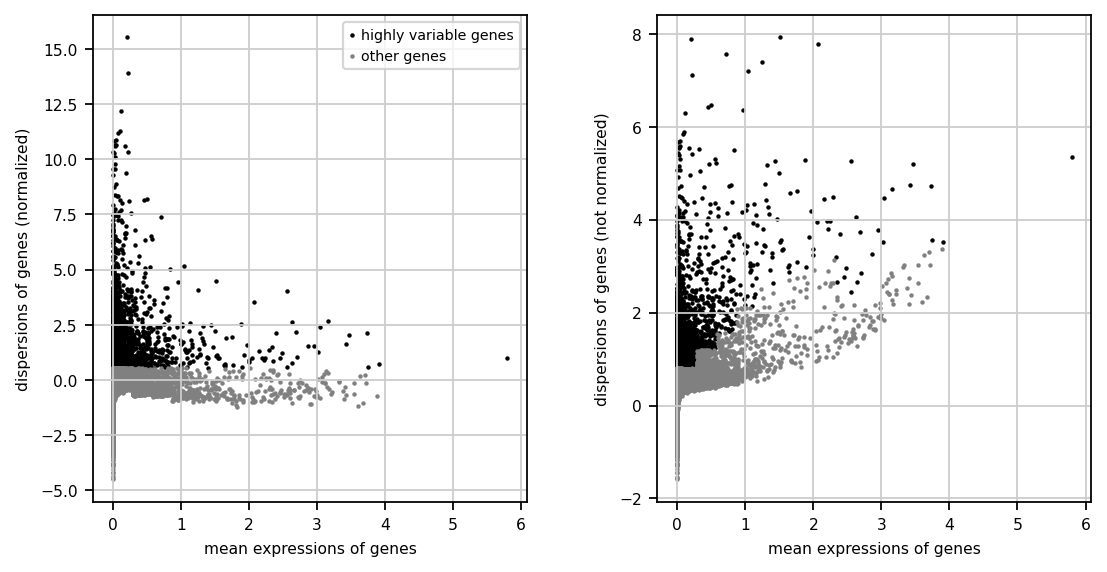

In [26]:
sc.pp.highly_variable_genes(adata, n_top_genes=4000)
sc.pl.highly_variable_genes(adata,save='.pdf')

In [27]:
adata.raw = adata # adata_norm = adata.raw.to_adata()
adata = adata[:, adata.var.highly_variable] 

In [28]:
%%time
#sc.tl.score_genes_cell_cycle(adata, s_genes=s_genes, g2m_genes=g2m_genes)
#sc.pp.regress_out(adata, ['S_score', 'G2M_score'])
#sc.pp.regress_out(adata, ['total_counts', 'pct_counts_mt'])
sc.pp.scale(adata, max_value=10)

/cluster/home/tmp02/.local/lib/python3.9/site-packages/scanpy/preprocessing/_scale.py:318: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/cluster/home/tmp02/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


CPU times: user 3.02 s, sys: 958 ms, total: 3.98 s
Wall time: 2.92 s


## PCA&CLUSTERING

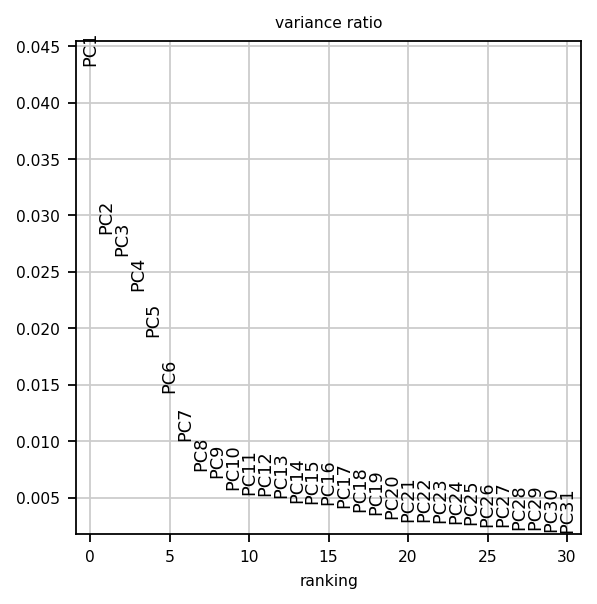

In [29]:
sc.tl.pca(adata, svd_solver='arpack')
sc.pl.pca_variance_ratio(adata, save='_elbow')

In [30]:
%%time
sc.pp.neighbors(adata, n_pcs=9)

CPU times: user 6.64 s, sys: 219 ms, total: 6.86 s
Wall time: 6.77 s


In [31]:
%%time
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution=0.1)

<timed exec>:2: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.


CPU times: user 1min 46s, sys: 3min 35s, total: 5min 21s
Wall time: 57.8 s


In [32]:
adata.obs ['sample']

AAACCTGCATGTAAGA      G1A
AAACCTGGTGTGACGA      G1A
AAACGGGAGGCTACGA      G1A
AAACGGGTCTTGTTTG      G1A
AAAGATGGTCAGAGGT      G1A
                     ... 
TTTGGAGTCCATACAG-1    G49
TTTGGTTCAGACAATA-1    G49
TTTGGTTTCCGTCCTA-1    G49
TTTGTTGAGAATTCAG-1    G49
TTTGTTGTCGATACGT-1    G49
Name: sample, Length: 47754, dtype: category
Categories (22, object): ['G1A', 'G2', 'G2A', 'G3', ..., 'G42', 'G45', 'G46', 'G49']

In [33]:
group = []
for x in list(adata.obs['sample']):
    if x in ['G1A', 'G2A', 'G3', 'G3A', 'G5', 'G38', 'G41', 'G46']:
        group.append('control')
    elif x in ['G2', 'G4','G6', 'G7', 'G8','G9', 'G15', 'G23','G33','G34','G39', 'G42', 'G45', 'G49']:
        group.append('DFU')
    else:
        group.append('Unknown')  

adata.obs['group'] = np.array(group)

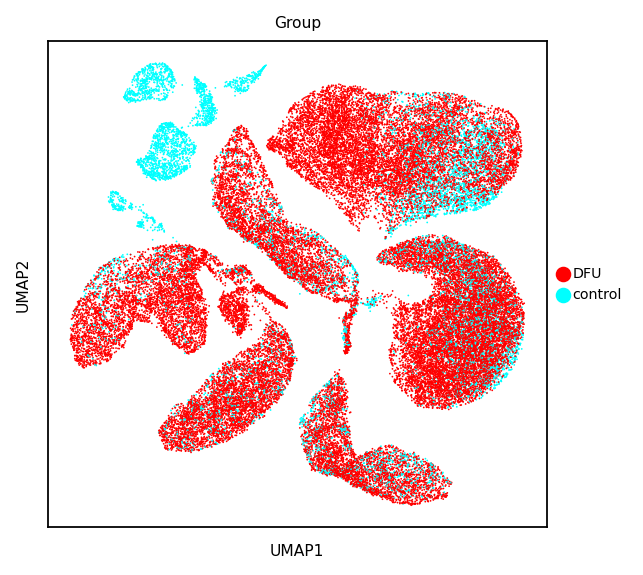

In [34]:
sc.pl.umap(adata, color=['group'],title='Group',palette={
        "DFU": "#FF0000FF",
      "control": "#00FFFFFF"},save='.group1.pdf') 

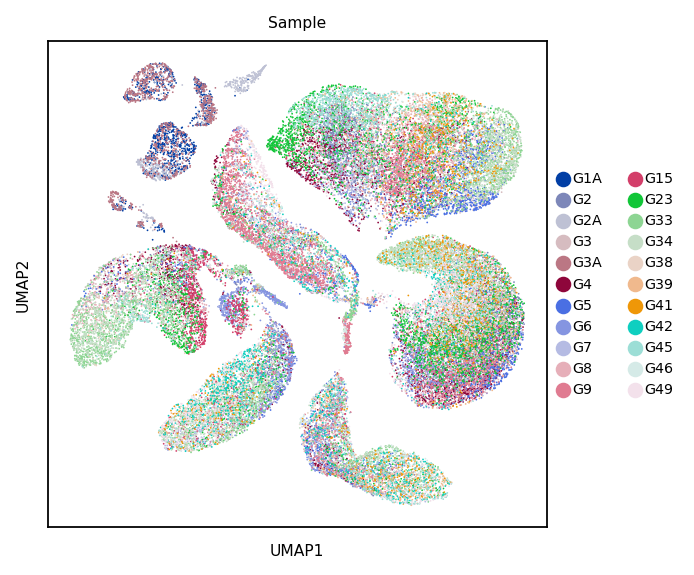

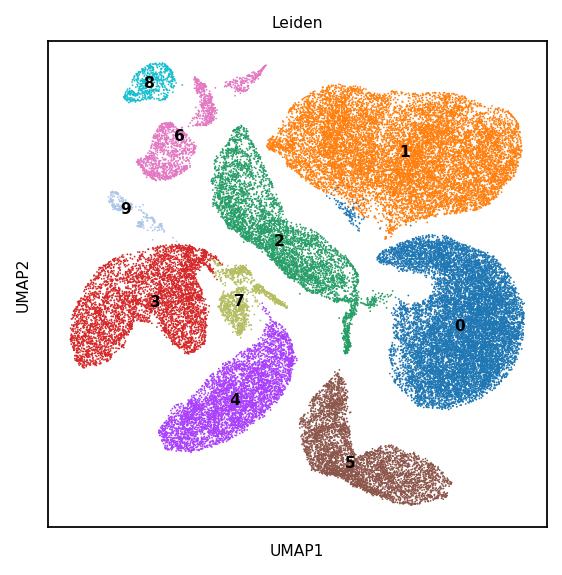

In [35]:
sc.pl.umap(adata, color=['sample'],title='Sample',save='.sample1.pdf')
sc.pl.umap(adata, color=['leiden'],title='Leiden',legend_loc='on data',save='.cluster1.pdf')

In [36]:
adata.write('/cluster/home/tmp02/GSE165816/0.1out/cluster.h5ad')

## Batch effect correction

In [37]:
adata = sc.read_h5ad('/cluster/home/tmp02/GSE165816/0.1out/cluster.h5ad')

/cluster/home/tmp02/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [38]:
%%time
sce.pp.harmony_integrate(adata, 'sample')

2024-12-11 16:02:46,433 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2024-12-11 16:02:51,583 - harmonypy - INFO - sklearn.KMeans initialization complete.
2024-12-11 16:02:51,967 - harmonypy - INFO - Iteration 1 of 10
2024-12-11 16:03:15,311 - harmonypy - INFO - Iteration 2 of 10
2024-12-11 16:03:37,727 - harmonypy - INFO - Iteration 3 of 10
2024-12-11 16:04:00,786 - harmonypy - INFO - Iteration 4 of 10
2024-12-11 16:04:23,322 - harmonypy - INFO - Iteration 5 of 10
2024-12-11 16:04:46,407 - harmonypy - INFO - Iteration 6 of 10
2024-12-11 16:05:09,323 - harmonypy - INFO - Iteration 7 of 10
2024-12-11 16:05:32,041 - harmonypy - INFO - Iteration 8 of 10
2024-12-11 16:05:51,605 - harmonypy - INFO - Iteration 9 of 10
2024-12-11 16:06:10,637 - harmonypy - INFO - Converged after 9 iterations


CPU times: user 12min 45s, sys: 3h 6min 35s, total: 3h 19min 20s
Wall time: 3min 25s


In [39]:
ad.logging.print_memory_usage()

Memory usage: current 5.00 GB, difference +2.28 GB


In [40]:
adata

AnnData object with n_obs × n_vars = 47754 × 4000
    obs: 'sample', 'doublet_score', 'predicted_doublet', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'group'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'group_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'sample_colors', 'scrublet', 'umap'
    obsm: 'X_pca', 'X_umap', 'X_pca_harmony'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [41]:
adata.obs

,sample,doublet_score,predicted_doublet,n_genes,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,leiden,group
AAACCTGCATGTAAGA,G1A,0.008046,False,1109,1109,2493.0,138.0,5.535500,6,control
AAACCTGGTGTGACGA,G1A,0.019264,False,832,832,1487.0,52.0,3.496974,8,control
AAACGGGAGGCTACGA,G1A,0.030257,False,2730,2730,9072.0,142.0,1.565256,6,control
AAACGGGTCTTGTTTG,G1A,0.035565,False,1501,1501,3134.0,59.0,1.882578,8,control
AAAGATGGTCAGAGGT,G1A,0.009174,False,1078,1078,2467.0,30.0,1.216052,6,control
...,...,...,...,...,...,...,...,...,...,...
TTTGGAGTCCATACAG-1,G49,0.042910,False,1797,1797,5257.0,654.0,12.440556,2,DFU
TTTGGTTCAGACAATA-1,G49,0.036348,False,3937,3937,15276.0,1122.0,7.344855,0,DFU
TTTGGTTTCCGTCCTA-1,G49,0.045411,False,3671,3671,13450.0,485.0,3.605948,0,DFU
TTTGTTGAGAATTCAG-1,G49,0.018845,False,2282,2282,4863.0,526.0,10.816368,5,DFU


In [42]:
adata.obsm['X_pca'] = adata.obsm['X_pca_harmony']

In [43]:
%%time
sc.pp.neighbors(adata, n_pcs=9)

CPU times: user 5.45 s, sys: 326 ms, total: 5.77 s
Wall time: 5.59 s


In [44]:
%%time
sc.tl.umap(adata)
sc.tl.leiden(adata,resolution=0.1)

CPU times: user 1min 34s, sys: 3min 2s, total: 4min 36s
Wall time: 54.4 s


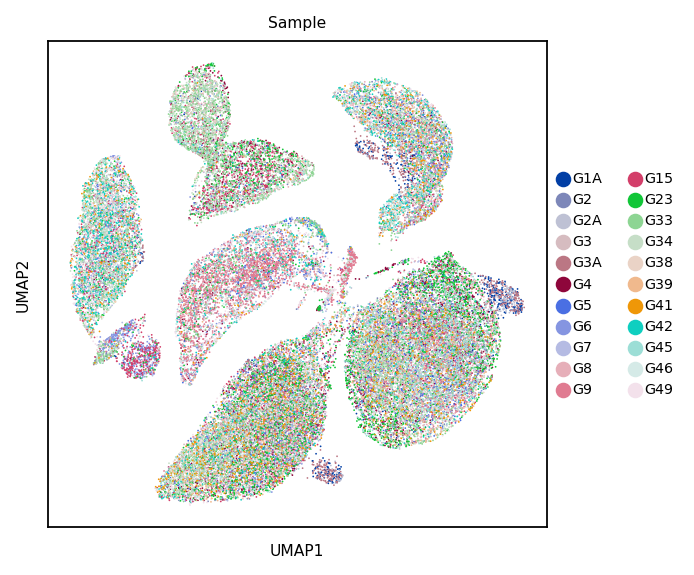

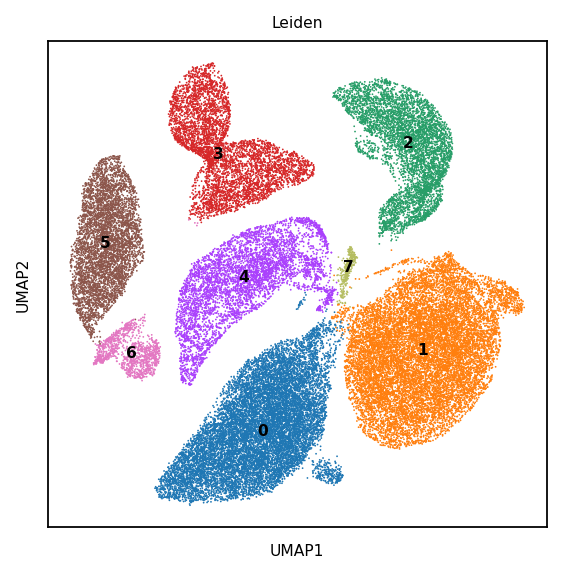

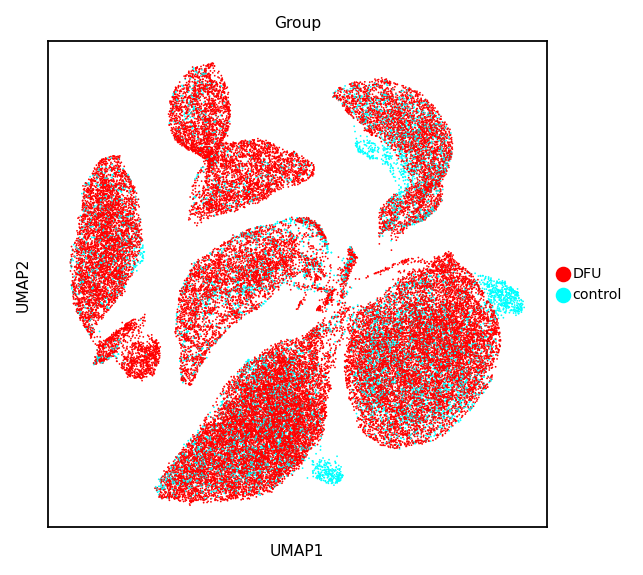

In [46]:
sc.pl.umap(adata, color=['sample'],title='Sample',save='.sample2.pdf')
sc.pl.umap(adata, color=['leiden'],title='Leiden',legend_loc='on data',save='.cluster3.pdf')
sc.pl.umap(adata, color=['group'],title='Group',save='.group2.pdf',palette={
        "DFU": "#D63423",
        "control": '#009CE4'})

/cluster/apps/anaconda3/2022.10/envs/scanpy-env/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:420: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
/cluster/apps/anaconda3/2022.10/envs/scanpy-env/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:420: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
/cluster/apps/anaconda3/2022.10/envs/scanpy-env/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:420: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
/cluster/apps/anaconda3/2022.10/envs/scanpy-env/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:420: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
/cluster/apps/anaconda3/2022.10/envs/scanpy-env/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:420: Runt

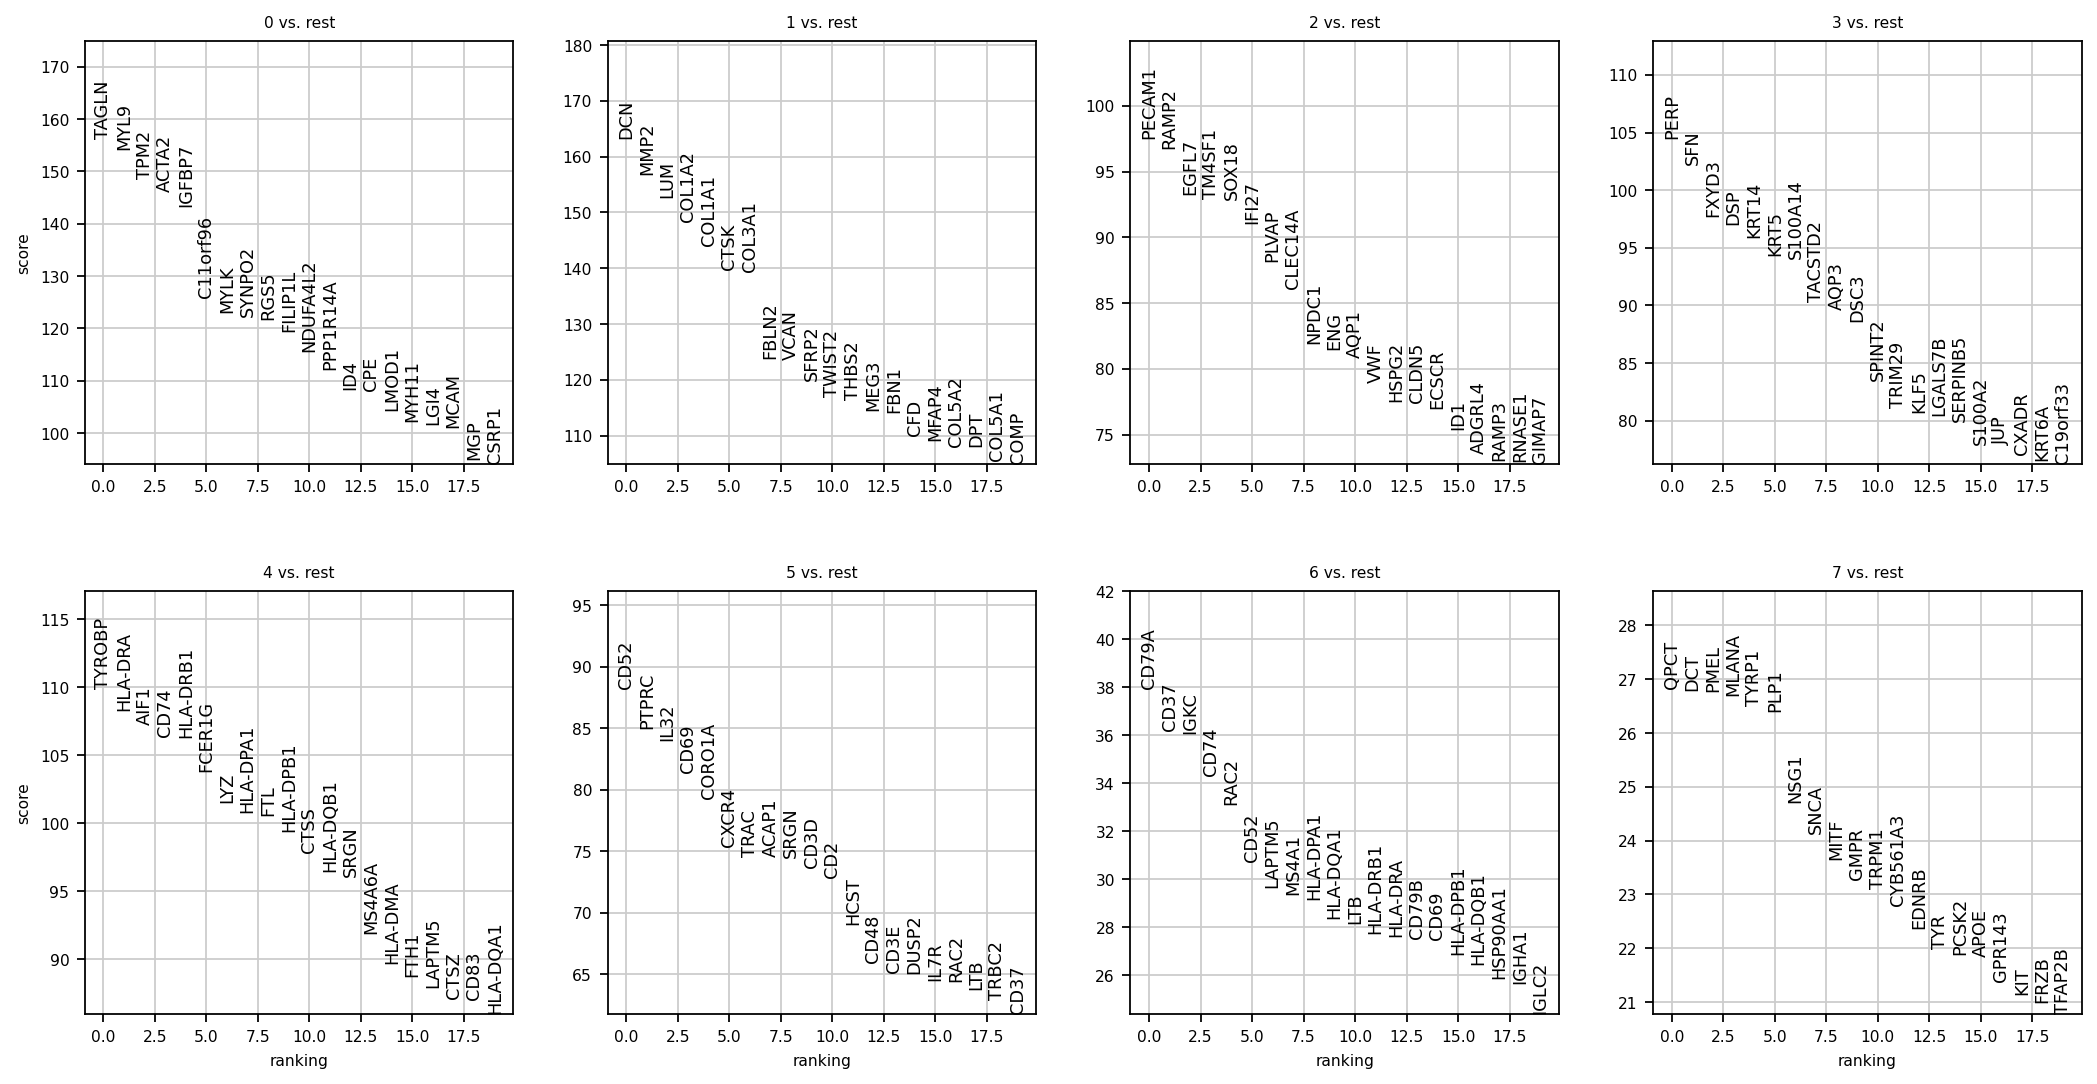

In [80]:
adata.uns['log1p']["base"] = None
sc.tl.rank_genes_groups(adata, 'leiden', method='wilcoxon',use_raw=False)
sc.pl.rank_genes_groups(adata, n_genes=20, save='.pdf',sharey=False)

In [84]:
hvg_table = adata.uns['rank_genes_groups']
groups = hvg_table['names'].dtype.names
hvgdf = pd.DataFrame(
    {group + '_' + key: hvg_table[key][group]
     for group in groups 
     for key in ['names', 'pvals','logfoldchanges']})
hvgdf.to_excel('./hvg_table.xlsx') 

In [85]:
pd.DataFrame(adata.uns['rank_genes_groups']['names']).head(10)

,0,1,2,3,4,5,6,7
0,TAGLN,DCN,PECAM1,PERP,TYROBP,CD52,CD79A,QPCT
1,MYL9,MMP2,RAMP2,SFN,HLA-DRA,PTPRC,CD37,DCT
2,TPM2,LUM,EGFL7,FXYD3,AIF1,IL32,IGKC,PMEL
3,ACTA2,COL1A2,TM4SF1,DSP,CD74,CD69,CD74,MLANA
4,IGFBP7,COL1A1,SOX18,KRT14,HLA-DRB1,CORO1A,RAC2,TYRP1
5,C11orf96,CTSK,IFI27,KRT5,FCER1G,CXCR4,CD52,PLP1
6,MYLK,COL3A1,PLVAP,S100A14,LYZ,TRAC,LAPTM5,NSG1
7,SYNPO2,FBLN2,CLEC14A,TACSTD2,HLA-DPA1,ACAP1,MS4A1,SNCA
8,RGS5,VCAN,NPDC1,AQP3,FTL,SRGN,HLA-DPA1,MITF
9,FILIP1L,SFRP2,ENG,DSC3,HLA-DPB1,CD3D,HLA-DQA1,GMPR


In [86]:
adata.write('./Final.h5ad') 